# Assignment - Log Mining + Parsing + Anomaly từ Log
## Phase 1: Parse Log với Drain3

In [17]:
from gen import LogAnalyzer

analyzer = LogAnalyzer('HDFS_2k.log')
lines = analyzer.load_log()
print(f"Total lines: {analyzer.total_lines}")

Loaded 2000 lines from HDFS_2k.log
Total lines: 2000


In [18]:
# Tune drain_sim_th
results = analyzer.tune_drain_sim_th([0.3, 0.5, 0.7])
print("Tuning results:", results)

sim_th=0.3 -> 17 templates
sim_th=0.5 -> 21 templates
sim_th=0.7 -> 820 templates
Tuning results: {0.3: 17, 0.5: 21, 0.7: 820}


In [19]:
# Parse with best sim_th (e.g., 0.5)
parsed = analyzer.parse_with_drain(sim_th=0.5)

Parsed logs. Found 21 templates with sim_th=0.5.


In [20]:
# Export top-10 templates
top_10 = analyzer.export_top_templates(10, 'results/top_templates.csv')
top_10

Exported top 10 templates to results/top_templates.csv


,template_id,template,count
0,2,<*> <*> <*> INFO dfs.FSNamesystem: BLOCK* Name...,314
1,1,<*> <*> <*> INFO dfs.DataNode$PacketResponder:...,311
2,3,<*> <*> <*> INFO dfs.DataNode$PacketResponder:...,292
3,4,<*> <*> <*> INFO dfs.DataNode$DataXceiver: Rec...,292
4,7,<*> <*> <*> INFO dfs.FSDataset: Deleting block...,263
5,11,<*> <*> <*> INFO dfs.FSNamesystem: BLOCK* Name...,224
6,9,<*> <*> <*> WARN dfs.DataNode$DataXceiver: <*>...,80
7,12,081110 <*> <*> INFO dfs.DataNode$DataXceiver: ...,59
8,16,081111 <*> <*> INFO dfs.FSNamesystem: BLOCK* N...,55
9,10,081110 <*> <*> INFO dfs.FSNamesystem: BLOCK* N...,52


## Phase 2: Anomaly Detection trên Log

In [21]:
# Create template count time series
ts = analyzer.extract_time_series(window='5min')
ts.head()

template_id,1,2,3,4,5,6,7,8,9,10,...,12,13,14,15,16,17,18,19,20,21
timestamp,,,,,,,,,,,,,,,,,,,,,
2008-11-09 20:35:00,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2008-11-09 20:40:00,2,4,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2008-11-09 20:45:00,1,1,2,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2008-11-09 20:50:00,1,1,2,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2008-11-09 20:55:00,0,3,2,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
# Detect anomalies using Isolation Forest
anomalies = analyzer.detect_anomalies_iforest(ts)
if anomalies is not None:
    display(anomalies[anomalies['anomaly'] == -1])

Found 16 anomalous time windows.


template_id,1,2,3,4,5,6,7,8,9,10,...,13,14,15,16,17,18,19,20,21,anomaly
timestamp,,,,,,,,,,,,,,,,,,,,,
2008-11-09 20:55:00,0,3,2,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,-1
2008-11-09 21:35:00,1,0,0,1,0,0,1,3,0,0,...,0,0,0,0,0,0,0,0,0,-1
2008-11-10 08:30:00,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,-1
2008-11-10 10:30:00,1,0,3,0,0,0,20,0,0,1,...,0,0,0,0,0,0,0,0,0,-1
2008-11-10 10:35:00,1,2,2,0,0,0,45,0,0,2,...,0,0,0,0,0,0,0,0,0,-1
2008-11-10 11:40:00,2,3,2,5,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,-1
2008-11-10 13:55:00,0,0,0,0,0,1,0,0,2,0,...,0,0,0,0,0,0,0,0,0,-1
2008-11-10 15:00:00,1,3,0,3,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,-1
2008-11-10 21:00:00,0,0,2,2,0,0,18,0,0,0,...,0,0,0,0,0,0,0,0,0,-1


Saved plot to assets/Template-count-time-series.png


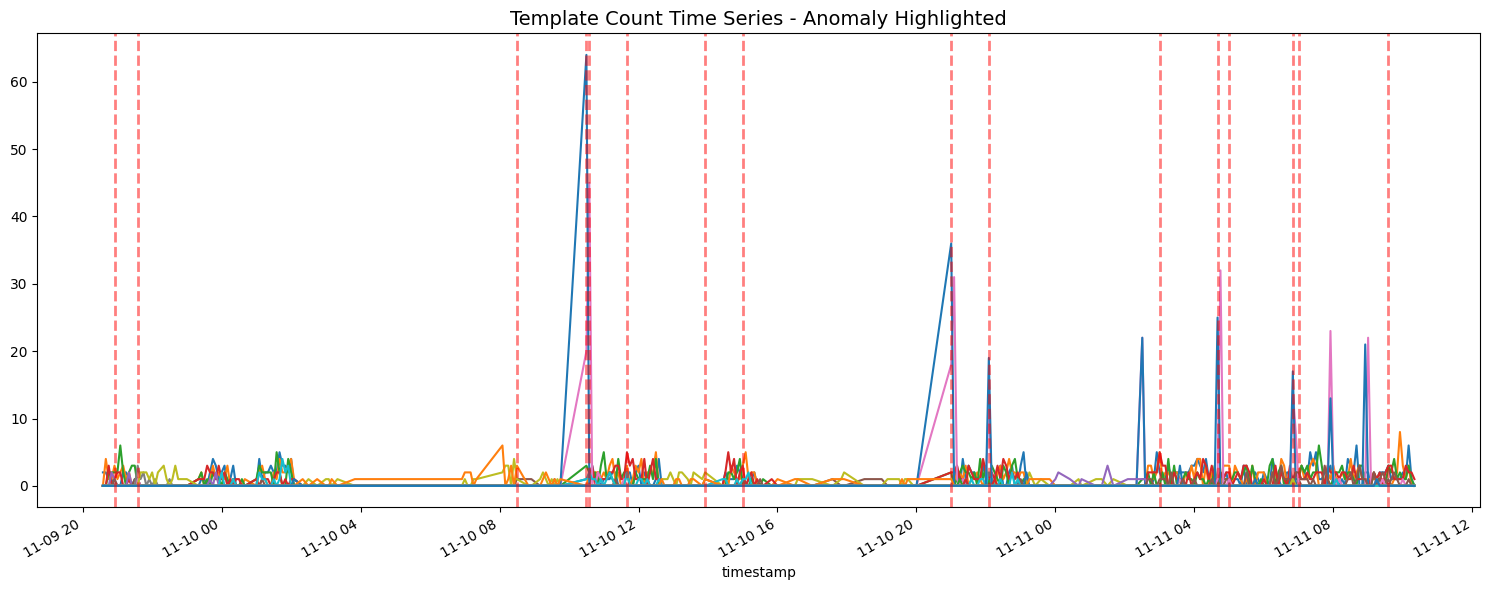

In [23]:
# Visualize one template spike if possible
import matplotlib.pyplot as plt
import os

if ts is not None and not ts.empty:
    fig, ax = plt.subplots(figsize=(15, 6))
    
    # Dùng bảng màu mặc định của pandas cho đẹp
    ts.plot(ax=ax, legend=False, linewidth=1.5)
    
    # Highlight Anomaly bằng đường kẻ dọc
    if anomalies is not None:
        anomaly_times = anomalies[anomalies["anomaly"] == -1].index
        for t in anomaly_times:
            ax.axvline(x=t, color="red", alpha=0.5, linestyle="--", linewidth=2)
            
    plt.title("Template Count Time Series - Anomaly Highlighted", fontsize=14)
    os.makedirs("assets", exist_ok=True)
    plt.tight_layout()
    plt.savefig("assets/Template-count-time-series.png", dpi=300)
    print("Saved plot to assets/Template-count-time-series.png")
    
    plt.show()


In [24]:
# Detect new templates appearing
new_templates = analyzer.detect_new_templates()
for nt in new_templates[:5]:
    print("New Template:", nt['template'])

Found 48 'new' template occurrences (each unique template counts once).
New Template: 081109 203615 148 INFO dfs.DataNode$PacketResponder: PacketResponder 1 for block blk_38865049064139660 terminating
New Template: 081109 <*> <*> INFO dfs.DataNode$PacketResponder: PacketResponder <*> for block <*> terminating
New Template: 081109 204005 35 INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: 10.251.73.220:50010 is added to blk_7128370237687728475 size 67108864
New Template: 081109 <*> <*> INFO dfs.FSNamesystem: BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size 67108864
New Template: 081109 204655 556 INFO dfs.DataNode$PacketResponder: Received block blk_3587508140051953248 of size 67108864 from /10.251.42.84


## Phase 3: Embedding + Cross-signal

In [25]:
# TF-IDF trên templates -> tìm template clusters
clusters, sim_matrix, templates, template_ids = analyzer.cluster_templates_tfidf(similarity_threshold=0.5)
print(f"Number of clusters: {len(clusters)}")
for i, cluster in enumerate(clusters[:5]):
    print(f"Cluster {i}: {cluster}")

Found 14 TF-IDF clusters using threshold 0.5.
Number of clusters: 14
Cluster 0: [1]
Cluster 1: [2]
Cluster 2: [3, 17]
Cluster 3: [4]
Cluster 4: [5, 10, 16]


In [26]:
# Inject 1 dòng log lạ
strange_log = "081110 203615 999 ERROR dfs.DataNode$PacketResponder: CRITICAL core meltdown detected in block blk_9999999999 terminating"
is_new, new_template = analyzer.inject_and_detect(strange_log)

Injecting strange log: 081110 203615 999 ERROR dfs.DataNode$PacketResponder: CRITICAL core meltdown detected in block blk_9999999999 terminating
DETECTED NEW TEMPLATE: 081110 203615 999 ERROR dfs.DataNode$PacketResponder: CRITICAL core meltdown detected in block blk_9999999999 terminating
